Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import json
import warnings
warnings.filterwarnings('ignore')

Data

In [ ]:
df = pd.read_csv("Financial Risk Classification Dataset.csv")
df.head()

,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
0,19,51140.401281,10,21,724.748104,3899.654973,60,9.577176,0.733655,2704.161100,...,3,0.692560,3,68,12,7.289109,0.540080,1,68,0
1,24,69028.631473,8,19,655.666339,21084.032813,48,8.383830,0.798551,2611.106393,...,1,0.469194,3,62,5,5.108674,0.007390,0,92,0
2,44,55186.372954,10,1,821.874508,28297.796011,24,7.321765,0.454056,2442.756164,...,1,0.001102,2,20,16,2.906073,0.704191,1,52,0
3,31,61403.651502,12,16,715.445294,38358.635271,12,5.997473,0.579187,2369.382349,...,2,0.753590,2,65,80,2.938127,0.701259,0,88,0
4,31,42536.559850,9,19,850.000000,46599.675272,36,9.115591,0.135722,2052.929537,...,1,0.364849,5,98,96,5.440193,0.524457,0,58,0


Cek Duplikasi

In [ ]:
duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat : {duplikat}")
if duplikat > 0:
    df = df.drop_duplicates()
    print(f"Duplikat dihapus. Shape baru: {df.shape}")


Jumlah baris duplikat : 0


Cek missing value dan Penanganan jika ada

In [ ]:
missing = df.isnull().sum()
print(f"Missing values per kolom:\n{missing}")

# Jika ada missing values, isi dengan strategi berikut:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            # Kolom numerik: isi dengan median (lebih robust terhadap outlier)
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  → [{col}] diisi dengan median: {df[col].median():.4f}")
        else:
            # Kolom kategorik: isi dengan modus
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  → [{col}] diisi dengan modus: {df[col].mode()[0]}")

print("Missing values setelah penanganan:", df.isnull().sum().sum())

Missing values per kolom:
age                           0
annual_income                 0
education_years               0
work_experience_years         0
credit_score                  0
loan_amount                   0
loan_duration_months          0
interest_rate                 0
debt_to_income_ratio          0
monthly_expenses              0
savings_balance               0
investment_balance            0
number_of_dependents          0
employment_stability_years    0
housing_status_score          0
marital_status_score          0
health_risk_index             0
insurance_coverage_score      0
spending_score                0
online_activity_score         0
device_usage_hours            0
location_risk_index           0
previous_default_count        0
financial_literacy_score      0
loan_default                  0
dtype: int64
Missing values setelah penanganan: 0


Penanganan imbalanced

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

print(f"Distribusi target sebelum balancing:\n{df['loan_default'].value_counts()}")
print(f"Rasio imbalance: {df['loan_default'].value_counts()[0] / df['loan_default'].value_counts().get(1, 1):.1f}:1")

X_raw = df.drop(columns=['loan_default'])
y_raw = df['loan_default']

minority_count = y_raw.value_counts().min()
print(f"\nJumlah sampel minoritas: {minority_count}")

if minority_count < 2:
    print("Sampel minoritas < 2 → menggunakan RandomOverSampler terlebih dahulu...")

    ros = RandomOverSampler(sampling_strategy={1: 6}, random_state=42)
    X_temp, y_temp = ros.fit_resample(X_raw, y_raw)

    print(f"Setelah RandomOverSampler (6 sampel minoritas): {pd.Series(y_temp).value_counts().to_dict()}")

    majority_count  = y_temp.value_counts()[0]
    target_minority = max(int(majority_count * 0.10), 50)  # minimal 50 sampel

    smote = SMOTE(
        sampling_strategy={1: target_minority},
        random_state=42,
        k_neighbors=5
    )
    X_resampled, y_resampled = smote.fit_resample(X_temp, y_temp)

else:
    k = min(5, minority_count - 1)
    print(f"Menggunakan SMOTE dengan k_neighbors={k}...")

    smote = SMOTE(random_state=42, k_neighbors=k)
    X_resampled, y_resampled = smote.fit_resample(X_raw, y_raw)

print(f"\nDistribusi target setelah balancing:\n{pd.Series(y_resampled).value_counts()}")
print(f"Shape setelah balancing: {X_resampled.shape}")

# Gabungkan kembali menjadi DataFrame
df = pd.DataFrame(X_resampled, columns=X_raw.columns)
df['loan_default'] = y_resampled

Distribusi target sebelum balancing:
loan_default
0    4999
1       1
Name: count, dtype: int64
Rasio imbalance: 4999.0:1

Jumlah sampel minoritas: 1
Sampel minoritas < 2 → menggunakan RandomOverSampler terlebih dahulu...
Setelah RandomOverSampler (6 sampel minoritas): {0: 4999, 1: 6}

Distribusi target setelah balancing:
loan_default
0    4999
1     499
Name: count, dtype: int64
Shape setelah balancing: (5498, 24)


Feature Engineering

In [ ]:
df['income_to_loan_ratio']      = df['annual_income'] / (df['loan_amount'] + 1)
df['savings_to_income_ratio']   = df['savings_balance'] / (df['annual_income'] + 1)
df['investment_to_income_ratio']= df['investment_balance'] / (df['annual_income'] + 1)
df['monthly_income']            = df['annual_income'] / 12
df['expense_to_income_ratio']   = df['monthly_expenses'] / (df['monthly_income'] + 1)
df['net_worth']                 = df['savings_balance'] + df['investment_balance'] - df['loan_amount']
df['experience_to_age_ratio']   = df['work_experience_years'] / (df['age'] + 1)

In [ ]:
# Kategori risiko berbasis credit score (untuk narasi chatbot)
df['credit_risk_category'] = pd.cut(
    df['credit_score'],
    bins=[0, 580, 669, 739, 799, 850],
    labels=['Very Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
).astype(str)

# Kategori usia (untuk segmentasi profil nasabah)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['Young Adult', 'Adult', 'Middle Age', 'Senior']
).astype(str)

# Kategori income
df['income_category'] = pd.cut(
    df['annual_income'],
    bins=[0, 30000, 50000, 75000, 100000, float('inf')],
    labels=['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']
).astype(str)

print("Fitur baru yang ditambahkan:")
new_features = [
    'income_to_loan_ratio', 'savings_to_income_ratio', 'investment_to_income_ratio',
    'monthly_income', 'expense_to_income_ratio', 'net_worth',
    'experience_to_age_ratio', 'credit_risk_category', 'age_group', 'income_category'
]
for f in new_features:
    print(f"  + {f}")

Fitur baru yang ditambahkan:
  + income_to_loan_ratio
  + savings_to_income_ratio
  + investment_to_income_ratio
  + monthly_income
  + expense_to_income_ratio
  + net_worth
  + experience_to_age_ratio
  + credit_risk_category
  + age_group
  + income_category


Preprocessing

In [ ]:
categorical_cols = ['credit_risk_category', 'age_group', 'income_category']

df_with_text = df.copy()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
print(f"Shape setelah encoding: {df_encoded.shape}")

feature_cols = [c for c in df_encoded.columns if c != 'loan_default']
X = df_encoded[feature_cols]
y = df_encoded['loan_default']

numerical_cols = [
    'age', 'annual_income', 'credit_score', 'loan_amount', 'loan_duration_months',
    'interest_rate', 'debt_to_income_ratio', 'monthly_expenses', 'savings_balance',
    'investment_balance', 'device_usage_hours', 'location_risk_index',
    'health_risk_index', 'income_to_loan_ratio', 'savings_to_income_ratio',
    'investment_to_income_ratio', 'monthly_income', 'expense_to_income_ratio',
    'net_worth', 'experience_to_age_ratio'
]

numerical_cols = [c for c in numerical_cols if c in X.columns]

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"Kolom yang di-scale ({len(numerical_cols)} kolom): {numerical_cols[:5]}... dst")

Shape setelah encoding: (5498, 46)
Kolom yang di-scale (20 kolom): ['age', 'annual_income', 'credit_score', 'loan_amount', 'loan_duration_months']... dst


Feature Selection

In [ ]:
K_BEST = 20
selector = SelectKBest(score_func=f_classif, k=K_BEST)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score'  : selector.scores_
}).sort_values('score', ascending=False)

selected_features = feature_scores.head(K_BEST)['feature'].tolist()

print(f"Top {K_BEST} fitur terpilih:")
for i, (feat, score) in enumerate(zip(
    feature_scores.head(K_BEST)['feature'],
    feature_scores.head(K_BEST)['score']
), 1):
    print(f"  {i:2d}. {feat:<40} score: {score:.2f}")

X_selected = X[selected_features]

Top 20 fitur terpilih:
   1. income_category_Low                      score: 25749.53
   2. investment_to_income_ratio               score: 25235.21
   3. credit_risk_category_Very Good           score: 3314.02
   4. monthly_income                           score: 3149.00
   5. annual_income                            score: 3149.00
   6. investment_balance                       score: 2729.78
   7. expense_to_income_ratio                  score: 2230.46
   8. device_usage_hours                       score: 1379.87
   9. age                                      score: 1333.82
  10. age_group_Senior                         score: 1192.90
  11. insurance_coverage_score                 score: 1042.55
  12. credit_score                             score: 954.62
  13. education_years                          score: 852.81
  14. debt_to_income_ratio                     score: 811.09
  15. financial_literacy_score                 score: 774.55
  16. marital_status_score                     sc

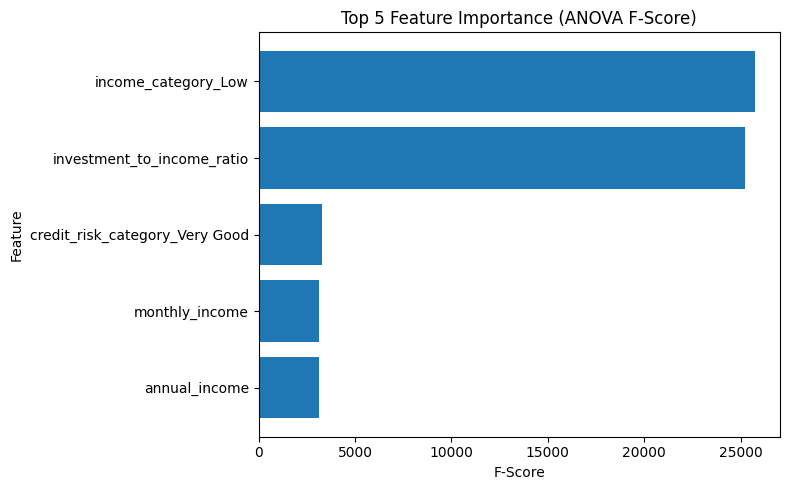

In [ ]:
import matplotlib.pyplot as plt

top5 = feature_scores.head(5)

plt.figure(figsize=(8,5))
plt.barh(top5['feature'][::-1], top5['score'][::-1])

plt.title('Top 5 Feature Importance (ANOVA F-Score)')
plt.xlabel('F-Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
# Simpan dataset hasil preprocessing
df_with_text.to_csv("full_preprocessed_with_text.csv",                   index=False)

# Simpan daftar selected features
with open("selected_features.json", "w") as f:
    json.dump({"selected_features": selected_features, "scaler_columns": numerical_cols}, f, indent=2)

# Simpan feature importance ranking
feature_scores.to_csv("feature_importance.csv", index=False)